# Implementação didática de Skip-gram em PyTorch

Este notebook apresenta uma implementação do modelo clássico do **Skip-gram**

## Objetivos
- entender a ideia central do Skip-gram
- construir os pares de treino `(palavra central -> palavra de contexto)`
- implementar o modelo em PyTorch
- treinar em um corpus pequeno
- inspecionar previsões e embeddings aprendidos

## Referência
Essa implementacao foi baseado no paper abaixo, que descreve a implementacao inicial com maior custo do Skip-Gram, sem otimizacoes descritas em outros papers como "Distributed Representations of Words and Phrases
and their Compositionality"

Tomas Mikolov, Kai Chen, Greg Corrado e Jeffrey Dean, **Efficient Estimation of Word Representations in Vector Space** (2013).

## O que é o Skip-gram?

No paper, o **Skip-gram** recebe a **palavra central** como entrada e tenta prever as **palavras ao redor dela**.

Em termos intuitivos:

> dada a palavra do meio, quais palavras de contexto deveriam aparecer perto dela?

Essa arquitetura é complementar ao CBOW:

- **CBOW**: contexto -> palavra central
- **Skip-gram**: palavra central -> contexto

## Observação importante

O artigo também discute treinamento eficiente em larga escala. Nesta versão didática, usamos:

- **softmax completo**
- um **corpus pequeno**
- uma implementação simples e legível

Isso torna o notebook mais fácil de estudar, ainda que não seja a versão mais eficiente para corpora muito grandes.

In [2]:
import re
import random
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Corpus didático

Para manter o notebook leve e rápido no Colab, usamos um corpus pequeno e repetido várias vezes.

Em um cenário real, o ideal seria usar muito mais dados.

In [3]:
base_sentences = [
    "o rei é um homem e a rainha é uma mulher",
    "o príncipe é um homem e a princesa é uma mulher",
    "o rei governa o reino e a rainha governa o palácio",
    "o príncipe vive no palácio e a princesa vive no castelo",
    "o gato é um animal doméstico e o cachorro é um animal doméstico",
    "o gato gosta de leite e o cachorro gosta de osso",
    "python é uma linguagem de programação",
    "pytorch é uma biblioteca para deep learning em python",
    "redes neurais aprendem padrões em dados",
    "aprendizado de máquina usa dados e modelos",
    "programação exige prática e estudo",
    "o carro é um veículo e o ônibus é um veículo",
    "o caminhão é um veículo grande",
    "são paulo fica no brasil",
    "uberlândia fica em minas gerais",
    "o brasil fica na américa do sul",
]

repeat_factor = 120
corpus = " ".join(base_sentences * repeat_factor)

print("Número de frases-base:", len(base_sentences))
print("Repeat factor:", repeat_factor)
print("Tamanho bruto do corpus (caracteres):", len(corpus))
print()
print(corpus[:500] + " ...")

Número de frases-base: 16
Repeat factor: 120
Tamanho bruto do corpus (caracteres): 82079

o rei é um homem e a rainha é uma mulher o príncipe é um homem e a princesa é uma mulher o rei governa o reino e a rainha governa o palácio o príncipe vive no palácio e a princesa vive no castelo o gato é um animal doméstico e o cachorro é um animal doméstico o gato gosta de leite e o cachorro gosta de osso python é uma linguagem de programação pytorch é uma biblioteca para deep learning em python redes neurais aprendem padrões em dados aprendizado de máquina usa dados e modelos programação exig ...


## 2. Tokenização e vocabulário

In [4]:
def tokenize(text: str):
    return re.findall(r"\b[\wà-úãõâêîôûç]+\b", text.lower())

tokens = tokenize(corpus)

special_tokens = ["<PAD>", "<UNK>"]
counter = Counter(tokens)
vocab = special_tokens + sorted(counter.keys())

stoi = {word: idx for idx, word in enumerate(vocab)}
itos = {idx: word for word, idx in stoi.items()}

def encode(word: str) -> int:
    return stoi.get(word, stoi["<UNK>"])

def decode(idx: int) -> str:
    return itos[idx]

print("Número total de tokens:", len(tokens))
print("Tamanho do vocabulário:", len(vocab))
print("Exemplo de tokens:", tokens[:20])

Número total de tokens: 16200
Tamanho do vocabulário: 65
Exemplo de tokens: ['o', 'rei', 'é', 'um', 'homem', 'e', 'a', 'rainha', 'é', 'uma', 'mulher', 'o', 'príncipe', 'é', 'um', 'homem', 'e', 'a', 'princesa', 'é']


## 3. Gerando exemplos de treino para Skip-gram

No Skip-gram, cada exemplo usa:

- uma **palavra central**
- uma **palavra de contexto** como alvo

Se `window_size = 2`, então para cada palavra central geramos pares com:

- 2 palavras à esquerda
- 2 palavras à direita

Ou seja, de uma única posição do corpus surgem vários pares de treino.

In [5]:
window_size = 2

centers = []
contexts = []

for i in range(window_size, len(tokens) - window_size):
    center_word = tokens[i]
    context_words = tokens[i - window_size : i] + tokens[i + 1 : i + window_size + 1]

    for context_word in context_words:
        centers.append(encode(center_word))
        contexts.append(encode(context_word))

print("Quantidade de pares de treino:", len(centers))
print()
print("Primeiro par codificado")
print("Centro:", centers[0])
print("Contexto:", contexts[0])
print()
print("Primeiro par decodificado")
print("Centro:", decode(centers[0]))
print("Contexto:", decode(contexts[0]))

Quantidade de pares de treino: 64784

Primeiro par codificado
Centro: 63
Contexto: 39

Primeiro par decodificado
Centro: é
Contexto: o


## 4. Dataset e DataLoader

In [6]:
class SkipGramDataset(Dataset):
    def __init__(self, centers, contexts):
        self.centers = torch.tensor(centers, dtype=torch.long)
        self.contexts = torch.tensor(contexts, dtype=torch.long)

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return self.centers[idx], self.contexts[idx]

dataset = SkipGramDataset(centers, contexts)
batch_size = 256
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

sample_x, sample_y = next(iter(dataloader))
print("Shape do batch de centros:", sample_x.shape)
print("Shape do batch de contextos:", sample_y.shape)

Shape do batch de centros: torch.Size([256])
Shape do batch de contextos: torch.Size([256])


## 5. Implementando o modelo Skip-gram em PyTorch

A lógica da arquitetura é:

1. a palavra central entra no modelo
2. ela é transformada em embedding
3. esse embedding é passado para uma camada linear
4. a saída representa uma distribuição sobre todo o vocabulário
5. o alvo é a palavra de contexto correta

Esta é a versão **didática**, usando softmax completo.

In [7]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_idxs):
        embedded = self.embedding(center_idxs)   # [B, D]
        logits = self.output(embedded)           # [B, V]
        return logits

vocab_size = len(vocab)
embedding_dim = 32

model = SkipGramModel(vocab_size=vocab_size, embedding_dim=embedding_dim).to(device)
print(model)

SkipGramModel(
  (embedding): Embedding(65, 32)
  (output): Linear(in_features=32, out_features=65, bias=True)
)


## 6. Treinamento

Vamos usar:

- `CrossEntropyLoss`
- `Adam`
- algumas épocas para o loss cair rapidamente

Como o corpus é pequeno e repetido, o treinamento converge de forma estável.

In [8]:
learning_rate = 1e-2
epochs = 6

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for batch_center, batch_context in dataloader:
        batch_center = batch_center.to(device)
        batch_context = batch_context.to(device)

        optimizer.zero_grad()
        logits = model(batch_center)
        loss = criterion(logits, batch_context)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    history.append(epoch_loss)
    print(f"Época {epoch:02d} | loss médio = {epoch_loss:.4f}")

Época 01 | loss médio = 2.4876
Época 02 | loss médio = 2.1954
Época 03 | loss médio = 2.1875
Época 04 | loss médio = 2.1826
Época 05 | loss médio = 2.1831
Época 06 | loss médio = 2.1777


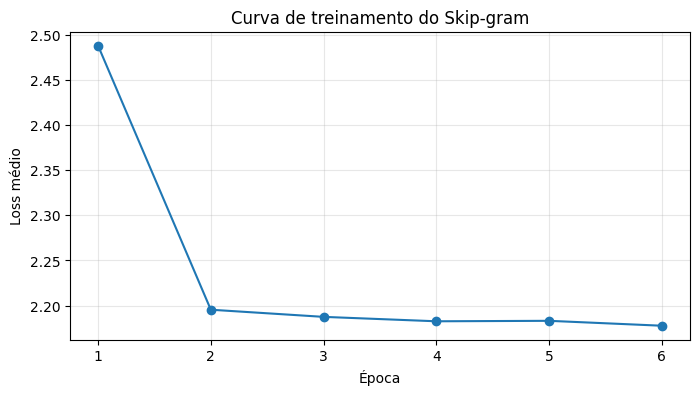

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("Época")
plt.ylabel("Loss médio")
plt.title("Curva de treinamento do Skip-gram")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Fazendo previsões de contexto

Dada uma palavra central, queremos descobrir quais palavras de contexto o modelo considera mais prováveis.

In [10]:
@torch.no_grad()
def predict_context_words(model, center_word, topk=5):
    model.eval()

    center_id = encode(center_word)
    x = torch.tensor([center_id], dtype=torch.long, device=device)

    logits = model(x)
    probs = torch.softmax(logits, dim=-1)
    values, indices = torch.topk(probs, k=topk, dim=-1)

    result = []
    for prob, idx in zip(values[0], indices[0]):
        result.append((decode(idx.item()), float(prob.item())))
    return result

test_words = ["rei", "rainha", "python", "gato", "brasil", "veículo"]

for word in test_words:
    print("Palavra central:", word)
    print("Top contextos previstos:", predict_context_words(model, word, topk=5))
    print("-" * 80)

Palavra central: rei
Top contextos previstos: [('o', 0.3279992341995239), ('governa', 0.20694100856781006), ('um', 0.14454568922519684), ('mulher', 0.14309363067150116), ('sul', 0.0902491882443428)]
--------------------------------------------------------------------------------
Palavra central: rainha
Top contextos previstos: [('a', 0.31322893500328064), ('e', 0.21041132509708405), ('governa', 0.1346869319677353), ('o', 0.12869806587696075), ('uma', 0.11923342198133469)]
--------------------------------------------------------------------------------
Palavra central: python
Top contextos previstos: [('learning', 0.22797620296478271), ('uma', 0.1540394425392151), ('de', 0.13812200725078583), ('neurais', 0.11914562433958054), ('redes', 0.1185024306178093)]
--------------------------------------------------------------------------------
Palavra central: gato
Top contextos previstos: [('o', 0.28040611743927), ('um', 0.18833856284618378), ('castelo', 0.15999923646450043), ('doméstico', 0.1

## 8. Inspecionando os embeddings aprendidos

Assim como no CBOW, os embeddings ficam em `model.embedding.weight`.

Vamos procurar vizinhos mais próximos com similaridade do cosseno.

In [11]:
@torch.no_grad()
def nearest_neighbors(model, word, topk=5):
    model.eval()

    if word not in stoi:
        raise ValueError(f"Palavra '{word}' não está no vocabulário.")

    emb = model.embedding.weight
    emb = emb / emb.norm(dim=1, keepdim=True).clamp_min(1e-12)

    word_idx = stoi[word]
    query = emb[word_idx]
    similarities = emb @ query

    values, indices = torch.topk(similarities, k=topk + 1)

    neighbors = []
    for sim, idx in zip(values.tolist(), indices.tolist()):
        token = decode(idx)
        if token == word:
            continue
        neighbors.append((token, sim))
        if len(neighbors) == topk:
            break

    return neighbors

for word in ["rei", "rainha", "python", "gato", "veículo", "brasil"]:
    print(f"Vizinhos de '{word}':")
    for neighbor, sim in nearest_neighbors(model, word, topk=5):
        print(f"  {neighbor:12s} -> {sim:.4f}")
    print()

Vizinhos de 'rei':
  caminhão     -> 0.3841
  gato         -> 0.3824
  mulher       -> 0.3645
  reino        -> 0.3630
  modelos      -> 0.3406

Vizinhos de 'rainha':
  princesa     -> 0.5235
  reino        -> 0.4537
  palácio      -> 0.4246
  homem        -> 0.3905
  doméstico    -> 0.3747

Vizinhos de 'python':
  mulher       -> 0.3706
  deep         -> 0.3669
  osso         -> 0.3366
  para         -> 0.3331
  padrões      -> 0.3003

Vizinhos de 'gato':
  animal       -> 0.4255
  rei          -> 0.3824
  ônibus       -> 0.3574
  príncipe     -> 0.3415
  leite        -> 0.3292

Vizinhos de 'veículo':
  ônibus       -> 0.4997
  carro        -> 0.4547
  caminhão     -> 0.4416
  homem        -> 0.4311
  paulo        -> 0.4103

Vizinhos de 'brasil':
  minas        -> 0.5043
  américa      -> 0.3800
  no           -> 0.3602
  paulo        -> 0.2983
  castelo      -> 0.2461



## 9. Visualização 2D dos embeddings

Vamos projetar alguns embeddings em 2 dimensões usando PCA.

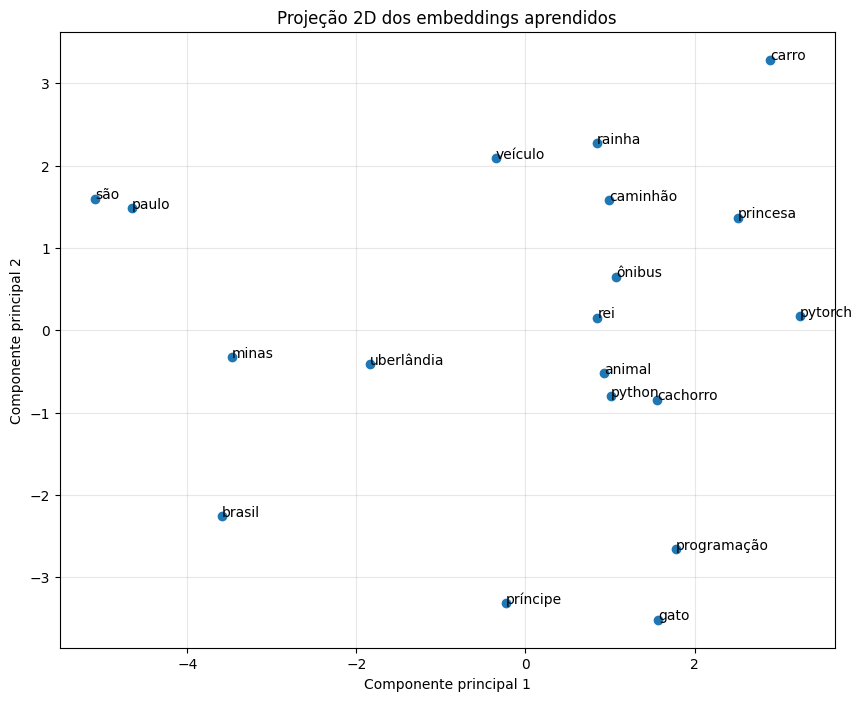

In [12]:
selected_words = [
    "rei", "rainha", "príncipe", "princesa",
    "gato", "cachorro", "animal",
    "python", "pytorch", "programação",
    "carro", "ônibus", "caminhão", "veículo",
    "brasil", "são", "paulo", "uberlândia", "minas",
]

selected_words = [w for w in selected_words if w in stoi]
selected_ids = torch.tensor([stoi[w] for w in selected_words], dtype=torch.long, device=device)

with torch.no_grad():
    E = model.embedding(selected_ids).detach().cpu()

E = E - E.mean(dim=0, keepdim=True)
U, S, V = torch.pca_lowrank(E, q=2)
coords = E @ V[:, :2]

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1])

for i, word in enumerate(selected_words):
    plt.annotate(word, (coords[i, 0].item(), coords[i, 1].item()))

plt.title("Projeção 2D dos embeddings aprendidos")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Relação conceitual entre CBOW e Skip-gram

Vale comparar os dois:

### CBOW
- usa várias palavras de contexto como entrada
- prevê a palavra central

### Skip-gram
- usa a palavra central como entrada
- prevê várias palavras de contexto
- gera mais pares de treino
- no paper, mostrou desempenho muito forte, especialmente em relações semânticas

## 11. Tornando a implementação mais próxima do paper

Para aproximar este notebook do cenário real descrito no artigo, podemos

1. trocar o corpus didático por um corpus real
2. usar janelas maiores
3. aumentar a dimensionalidade dos embeddings
4. treinar por mais tempo
5. substituir o softmax completo por alternativas mais eficientes, como:
   - **hierarchical softmax**
   - **negative sampling**

Em larga escala, essas escolhas fazem muita diferença no custo computacional.

In [13]:
# Exemplo opcional para usar um texto próprio no Google Colab:
#
# try:
#     from google.colab import files
#     uploaded = files.upload()
#     filename = next(iter(uploaded))
#     with open(filename, "r", encoding="utf-8") as f:
#         corpus = f.read()
#     print("Novo corpus carregado com sucesso.")
# except Exception as e:
#     print("Este bloco é opcional e foi pensado para o Google Colab.")
#     print("Detalhe:", e)

## 12. Resumo

Nesta implementação, o fluxo do Skip-gram ficou assim:

**palavra central -> embedding -> camada linear -> distribuição sobre o vocabulário -> palavra de contexto**

Essa é a essência do modelo:

- representar palavras como vetores densos
- usar uma palavra para prever seu contexto
- aprender embeddings úteis a partir dessa tarefa

Este notebook é uma boa base para comparar Skip-gram e CBOW lado a lado.